# Evaluación de los modelos de clasificación

De cada uno de los 7 algoritmos se toma su mejor combinación (balanceo, optimizador) según el
AUC-ROC **medio del bucle externo** (nunca según la prueba), se reentrena sobre todo el desarrollo
(246 mil filas) con los hiperparámetros del pliegue externo de mayor AUC interno, y se evalúa **una
sola vez** sobre la prueba (61,503 filas): la misma partición de la línea base logística del
entregable anterior, que se incluye como referencia.

Contenido: métricas (Sección 5.1.1), matrices de confusión, curvas ROC, comparación de técnicas de
balanceo (5.1.2) y calibración de probabilidades (5.1.3).

## Métrica principal de validación

**AUC-ROC** es el criterio de selección de todo el proyecto:

* mide la capacidad de **ordenar** a los solicitantes por riesgo, que es lo que el negocio usa
  (aprobar de menor a mayor riesgo hasta un punto de corte), y no depende del umbral;
* no se deja engañar por el desbalance como la exactitud: un modelo que responde siempre "cumple"
  acierta el 91.9 % y tiene AUC 0.5;
* es la métrica oficial del problema en Kaggle y la de la línea base, lo que hace comparables los
  resultados.

**En la decisión, el recall pesa más que la precisión.** Un falso negativo (aprobar a quien no va a
pagar) cuesta el capital prestado; un falso positivo (rechazar a un buen cliente) cuesta el margen de
un crédito. Por eso el umbral de cada modelo se fija minimizando `10·FN + FP` sobre predicciones
internas fuera de muestra, lo que empuja el punto de operación hacia recall alto. Se reportan además
precisión, F1 y AUC-PR, esta última más sensible a lo que ocurre en la clase minoritaria.

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
# los procesos paralelos de joblib (loky) tambien deben encontrar `src`
os.environ["PYTHONPATH"] = str(RAIZ) + os.pathsep + os.environ.get("PYTHONPATH", "")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
config.crear_directorios()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
from src import experimento as ex, finales as fin, metricas as met, datos, modelos as mod
from src import estadistica as est_
from src.graficos import COLOR_BAL, PALETA

pliegues, maestra = ex.consolidar()
conj = datos.cargar_traspaso()
finalistas = fin.seleccionar_finalistas(maestra, "clasificacion")
display(finalistas[["modelo", "balanceo", "optimizador", "m_auc_roc_media", "m_auc_roc_sd",
                    "m_recall_media", "m_f1_media"]].style.format(precision=4).hide(axis="index"))

modelo,balanceo,optimizador,m_auc_roc_media,m_auc_roc_sd,m_recall_media,m_f1_media
xgboost,ninguno,genetica,0.7721,0.0038,0.6591,0.2863
svm,class_weight,genetica,0.7578,0.0031,0.6575,0.2733
logistica,class_weight,bayesiana,0.7576,0.0028,0.6495,0.2753
random_forest,class_weight,aleatoria,0.7497,0.0035,0.6689,0.2643
arbol,ninguno,genetica,0.6965,0.0060,0.5902,0.2338
knn,ninguno,rejilla,0.6887,0.0013,0.5532,0.2329
naive_bayes,ninguno,genetica,0.6464,0.0019,0.5524,0.2136


## 1. Modelos finales

Cada modelo se guarda en `resultados/finales/` apenas termina; re-ejecutar la celda salta los
hechos, y un fallo en uno no afecta a los otros.

In [3]:
tabla_final = fin.evaluar_finalistas(conj, "clasificacion", finalistas)
F = fin.cargar_finales("clasificacion")
print(f"Modelos finales disponibles: {len(F)} de 7")

  xgboost        ya evaluado
  svm            ya evaluado
  logistica      ya evaluado
  random_forest  ya evaluado
  arbol          ya evaluado
  knn            ya evaluado
  naive_bayes    ya evaluado


Modelos finales disponibles: 7 de 7


In [4]:
# Línea base del entregable anterior (se aplica el pipeline guardado sobre la misma prueba)
ruta_base = config.RAIZ / "modelo_logistico.joblib"
BASE = None
if ruta_base.is_file() and not config.MODO_PRUEBA:
    import joblib
    art = joblib.load(ruta_base)
    s_base = art["pipeline"].predict_proba(conj.X_te[art["columnas"]])[:, 1]
    BASE = {"s": s_base, "y": conj.y_te.to_numpy(), "fila": conj.X_te.index.to_numpy(),
            "umbral": art["umbral"]}
    np.savez_compressed(config.DIR_FINALES / "linea_base_e2.npz", s=s_base, y=BASE["y"],
                        fila=BASE["fila"], umbral=art["umbral"])
    print(f"Línea base cargada: AUC prueba {roc_auc_score(BASE['y'], s_base):.4f}")
else:
    print("No se encontró modelo_logistico.joblib (se genera al ejecutar el capítulo 01).")

Línea base cargada: AUC prueba 0.7603


## 2. Métricas en prueba (Sección 5.1.1)

In [5]:
filas = []
for m, d in F.items():
    r = d["registro"]; mt = r["metricas"]
    filas.append({"Modelo": m, "Balanceo": r["balanceo"], "Optimizador": r["optimizador"],
                  "Accuracy": mt["exactitud"], "Precision": mt["precision"], "Recall": mt["recall"],
                  "F1-score": mt["f1"], "AUC": mt["auc_roc"], "AUC-PR": mt["auc_pr"],
                  "Umbral": mt["umbral"], "AUC CV (media ± sd)": f"{r['auc_cv_media']:.4f} ± {r['auc_cv_sd']:.4f}"})
if BASE is not None:
    mt = met.metricas_clasificacion(BASE["y"], BASE["s"], BASE["umbral"])
    filas.append({"Modelo": "línea base E2 (logística)", "Balanceo": "class_weight",
                  "Optimizador": "rejilla (E2)", "Accuracy": mt["exactitud"],
                  "Precision": mt["precision"], "Recall": mt["recall"], "F1-score": mt["f1"],
                  "AUC": mt["auc_roc"], "AUC-PR": mt["auc_pr"], "Umbral": mt["umbral"],
                  "AUC CV (media ± sd)": "-"})
metricas_prueba = pd.DataFrame(filas).sort_values("AUC", ascending=False)
metricas_prueba.to_csv(config.DIR_RESULTADOS / "metricas_prueba_clasificacion.csv", index=False)
display(metricas_prueba.style.format(precision=4).hide(axis="index")
        .background_gradient(subset=["AUC"], cmap="Blues"))

Modelo,Balanceo,Optimizador,Accuracy,Precision,Recall,F1-score,AUC,AUC-PR,Umbral,AUC CV (media ± sd)
xgboost,ninguno,genetica,0.7392,0.1871,0.6669,0.2922,0.7754,0.2696,0.0894,0.7721 ± 0.0038
línea base E2 (logística),class_weight,rejilla (E2),0.7450,0.1830,0.6232,0.2829,0.7603,0.2421,0.5409,-
logistica,class_weight,bayesiana,0.7211,0.1744,0.6574,0.2757,0.7597,0.2393,0.5221,0.7576 ± 0.0028
svm,class_weight,genetica,0.7187,0.1732,0.6580,0.2742,0.7595,0.2424,0.0294,0.7578 ± 0.0031
random_forest,class_weight,aleatoria,0.6964,0.1655,0.6832,0.2665,0.7544,0.2321,0.3841,0.7497 ± 0.0035
arbol,ninguno,genetica,0.6840,0.1474,0.6091,0.2373,0.7017,0.1782,0.0917,0.6965 ± 0.0060
knn,ninguno,rejilla,0.7045,0.1501,0.5706,0.2377,0.6975,0.1762,0.0904,0.6887 ± 0.0013
naive_bayes,ninguno,genetica,0.6854,0.1353,0.5374,0.2162,0.6477,0.1286,0.9439,0.6464 ± 0.0019


## 3. Matrices de confusión (umbral de coste elegido en validación interna)

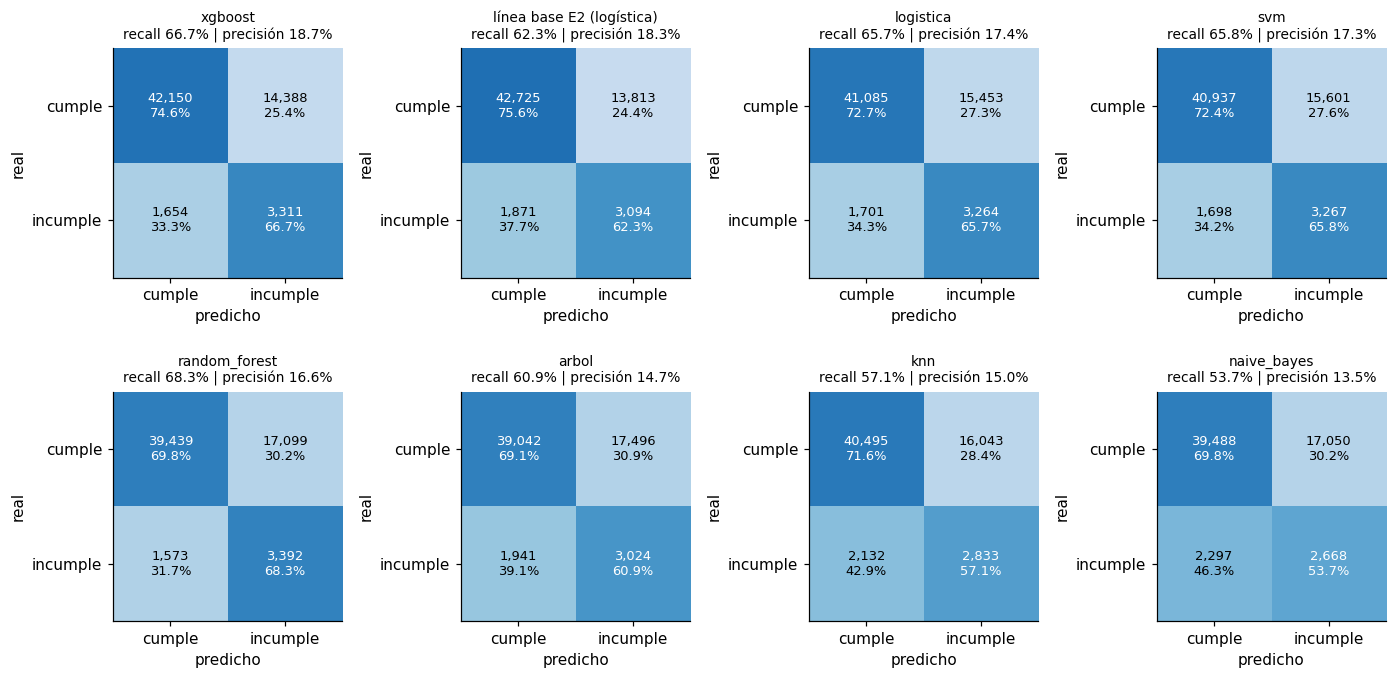

In [6]:
modelos_orden = metricas_prueba["Modelo"].tolist()
n = len(modelos_orden)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(3.2 * ((n + 1) // 2), 6.4))
for ax, m in zip(axes.ravel(), modelos_orden):
    if m in F:
        y, s, u = F[m]["y"], F[m]["s"], F[m]["registro"]["metricas"]["umbral"]
    else:
        y, s, u = BASE["y"], BASE["s"], BASE["umbral"]
    mt = met.metricas_clasificacion(y, s, u)
    M = np.array([[mt["tn"], mt["fp"]], [mt["fn"], mt["tp"]]])
    ax.imshow(M / M.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{M[i, j]:,}\n{100 * M[i, j] / M[i].sum():.1f}%", ha="center",
                    va="center", fontsize=8.5, color="white" if M[i, j] / M[i].sum() > 0.5 else "black")
    ax.set_xticks([0, 1], ["cumple", "incumple"]); ax.set_yticks([0, 1], ["cumple", "incumple"])
    ax.set_xlabel("predicho"); ax.set_ylabel("real"); ax.grid(False)
    ax.set_title(f"{m}\nrecall {mt['recall']:.1%} | precisión {mt['precision']:.1%}", fontsize=9)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.tight_layout()
graficos.guardar(fig, "06_matrices_confusion")
plt.show()

## 4. Curvas ROC

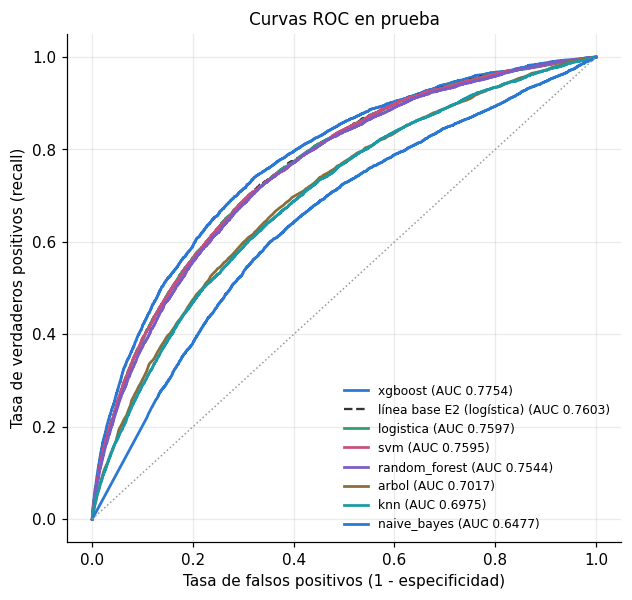

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for i, m in enumerate(modelos_orden):
    y, s = (F[m]["y"], F[m]["s"]) if m in F else (BASE["y"], BASE["s"])
    fpr, tpr, _ = roc_curve(y, s)
    estilo = dict(color="0.2", ls="--", lw=1.5) if m not in F else dict(color=PALETA[i % 7], lw=1.8)
    ax.plot(fpr, tpr, label=f"{m} (AUC {roc_auc_score(y, s):.4f})", **estilo)
ax.plot([0, 1], [0, 1], color="0.6", lw=1, ls=":")
ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Curvas ROC en prueba")
ax.legend(loc="lower right", fontsize=8)
graficos.guardar(fig, "06_roc")
plt.show()

## 5. Comparación de técnicas de balanceo (Sección 5.1.2)

Se usan todas las unidades del estudio (4 optimizadores x 5 pliegues = 20 mediciones por celda
modelo-balanceo), no solo la mejor. Para cada modelo, la diferencia de cada técnica frente a "sin
balanceo" se prueba de forma **pareada** (mismo optimizador, mismo pliegue) con Wilcoxon, ajustando
por Holm dentro de cada modelo.

Predicción teórica del capítulo 02: en Naive Bayes y KNN, `class_weight` no puede cambiar el AUC
(solo desplaza el umbral). Si el optimizador recibe exactamente los mismos AUC, recorre el mismo
camino y elige los mismos hiperparámetros: la diferencia debe ser **cero**, salvo diferencias numéricas por empates.

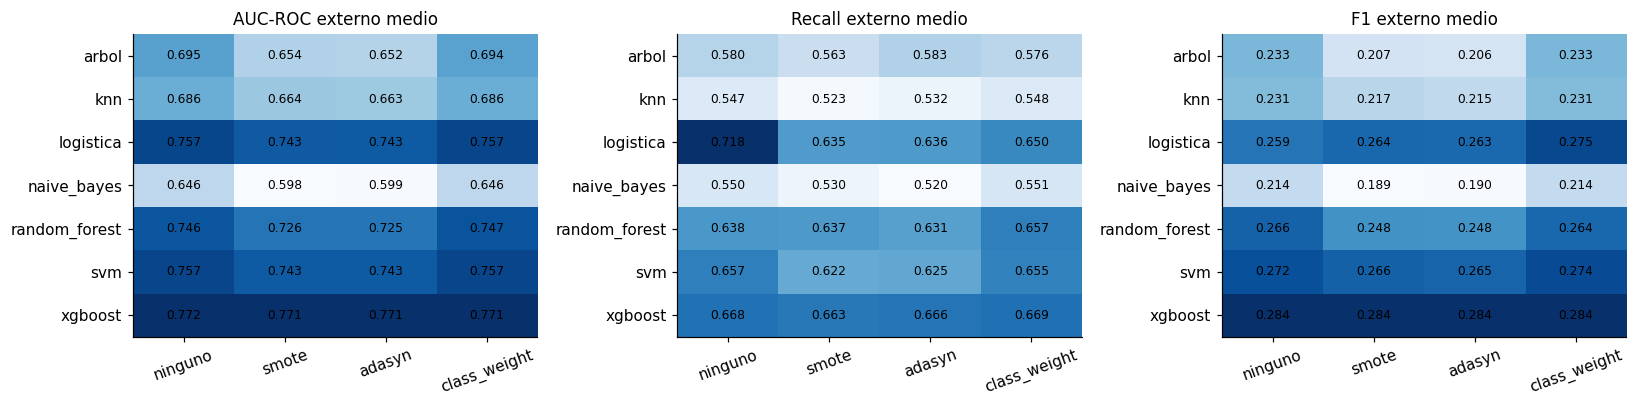

In [8]:
clf = pliegues[pliegues["tarea"] == "clasificacion"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (col, nombre) in zip(axes, [("m_auc_roc", "AUC-ROC"), ("m_recall", "Recall"), ("m_f1", "F1")]):
    T = clf.pivot_table(index="modelo", columns="balanceo", values=col, aggfunc="mean")
    T = T[["ninguno", "smote", "adasyn", "class_weight"]]
    im = ax.imshow(T.to_numpy(), cmap="Blues", aspect="auto")
    ax.set_xticks(range(4), T.columns, rotation=20); ax.set_yticks(range(len(T)), T.index)
    for i in range(T.shape[0]):
        for j in range(4):
            ax.text(j, i, f"{T.iat[i, j]:.3f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"{nombre} externo medio"); ax.grid(False)
fig.tight_layout()
graficos.guardar(fig, "06_balanceo")
plt.show()

In [9]:
from scipy.stats import wilcoxon
def stats_w(d):
    return np.nan if np.allclose(d, 0) else wilcoxon(d, zero_method="zsplit").pvalue
filas = []
for m, g in clf.groupby("modelo"):
    base_ = g[g["balanceo"] == "ninguno"].set_index(["optimizador", "pliegue"])
    for b in ("smote", "adasyn", "class_weight"):
        o = g[g["balanceo"] == b].set_index(["optimizador", "pliegue"])
        comun = base_.index.intersection(o.index)
        for col in ("m_auc_roc", "m_recall", "m_f1"):
            d = o.loc[comun, col] - base_.loc[comun, col]
            filas.append({"modelo": m, "balanceo": b, "metrica": col[2:], "n": len(d),
                          "delta_media": d.mean(), "delta_sd": d.std(),
                          "max_abs_delta": d.abs().max(),
                          "p_wilcoxon": stats_w(d) if len(d) > 5 else np.nan})
efecto_bal = pd.DataFrame(filas)
efecto_bal["p_holm"] = np.nan
for (m, mt), g in efecto_bal.groupby(["modelo", "metrica"]):
    ok = g["p_wilcoxon"].notna()
    if ok.any():
        efecto_bal.loc[g.index[ok], "p_holm"] = est_.ajustar_p(g.loc[ok, "p_wilcoxon"])["p_holm"].to_numpy()
efecto_bal.to_csv(config.DIR_RESULTADOS / "efecto_balanceo.csv", index=False)
display(efecto_bal[efecto_bal["metrica"] == "auc_roc"].style.format(precision=4).hide(axis="index"))

inv = efecto_bal[(efecto_bal["balanceo"] == "class_weight") & (efecto_bal["metrica"] == "auc_roc")
                 & (efecto_bal["modelo"].isin(["naive_bayes", "knn"]))]
print("Verificación de invariancia del AUC con class_weight (NB y KNN):")
display(inv[["modelo", "max_abs_delta"]])

modelo,balanceo,metrica,n,delta_media,delta_sd,max_abs_delta,p_wilcoxon,p_holm
arbol,smote,auc_roc,20,-0.0413,0.0081,0.0578,0.0000,0.0000
arbol,adasyn,auc_roc,20,-0.0431,0.0059,0.0532,0.0000,0.0000
arbol,class_weight,auc_roc,20,-0.0010,0.0056,0.0115,0.4749,0.4749
knn,smote,auc_roc,20,-0.0213,0.0042,0.0280,0.0000,0.0000
knn,adasyn,auc_roc,20,-0.0225,0.0036,0.0287,0.0000,0.0000
knn,class_weight,auc_roc,20,0.0000,0.0003,0.0011,0.3506,0.3506
logistica,smote,auc_roc,20,-0.0133,0.0021,0.0183,0.0000,0.0000
logistica,adasyn,auc_roc,20,-0.0137,0.0020,0.0184,0.0000,0.0000
logistica,class_weight,auc_roc,20,0.0007,0.0006,0.0016,0.0002,0.0002
naive_bayes,smote,auc_roc,20,-0.0478,0.0035,0.0544,0.0001,0.0003


Verificación de invariancia del AUC con class_weight (NB y KNN):


,modelo,max_abs_delta
15,knn,0.001134
33,naive_bayes,0.000363


**Lectura.** El balanceo actúa sobre el punto de operación más que sobre el ordenamiento, y cuando
toca el ordenamiento lo empeora. SMOTE y ADASYN bajan el AUC en seis de las siete familias, siempre
con significación tras Holm y con magnitudes muy por encima del ruido (≈ 0.003): −0.013/−0.014 en
logística y SVM, −0.020/−0.022 en Random Forest y KNN, −0.041/−0.043 en el árbol y −0.047/−0.048 en
Naive Bayes. En XGBoost el efecto es de −0.001: significativo con 20 pares, pero irrelevante.
`class_weight` deja el AUC prácticamente igual en todas las familias (|Δ| medio ≤ 0.0011); en
logística y SVM sube 0.0007 y 0.0005, cambios significativos pero sin importancia práctica, que se
explican porque en un modelo discriminativo ponderar sí modifica la función de pérdida y no solo
desplaza el puntaje.

En recall y F1 tampoco hay ganancia. Como el umbral se elige por coste en la validación interna de
cada combinación, todas las técnicas terminan en puntos de operación parecidos: el sobremuestreo no
aporta recall adicional (la logística sin balanceo tiene recall medio 0.718 frente a 0.635 con
SMOTE) y el F1 baja con SMOTE o ADASYN en cinco de las siete familias (en la logística sube 0.005 y en
XGBoost no cambia). La técnica preferible es, en consecuencia, ninguna o `class_weight`, en todas las
familias.

La verificación de invariancia confirma la predicción teórica: en Naive Bayes y KNN la diferencia de
AUC con `class_weight` es a lo sumo 0.0004 y 0.0011 en un pliegue, sin significación (p de Holm 0.086
y 0.35). Esos residuos se explican por empates numéricos, no por un cambio en el orden de los
puntajes.

## 6. Calibración de probabilidades (Sección 5.1.3)

Un modelo puede ordenar bien (AUC alto) y aun así producir probabilidades que no reflejan la
frecuencia real del evento. Se evalúa con el diagrama de confiabilidad (bins de igual frecuencia), el
**Brier score** y el **ECE**. Se esperan dos fuentes de descalibración:

* **balanceo**: SMOTE, ADASYN y `class_weight` entrenan con ~33-50 % de positivos cuando la realidad es
  8 %, lo que infla todas las probabilidades (desplazamiento del prior);
* **el propio algoritmo**: SVM no produce probabilidades (su puntaje es una distancia al hiperplano),
  Naive Bayes empuja las probabilidades a los extremos por el supuesto de independencia, y los
  bosques las comprimen hacia el centro.

La recalibración (Platt o isotónica) se ajusta con las **predicciones fuera de muestra de la CV anidada
sobre desarrollo** de la misma combinación, y se aplica a la prueba. La prueba nunca se usa para
ajustar el recalibrador.

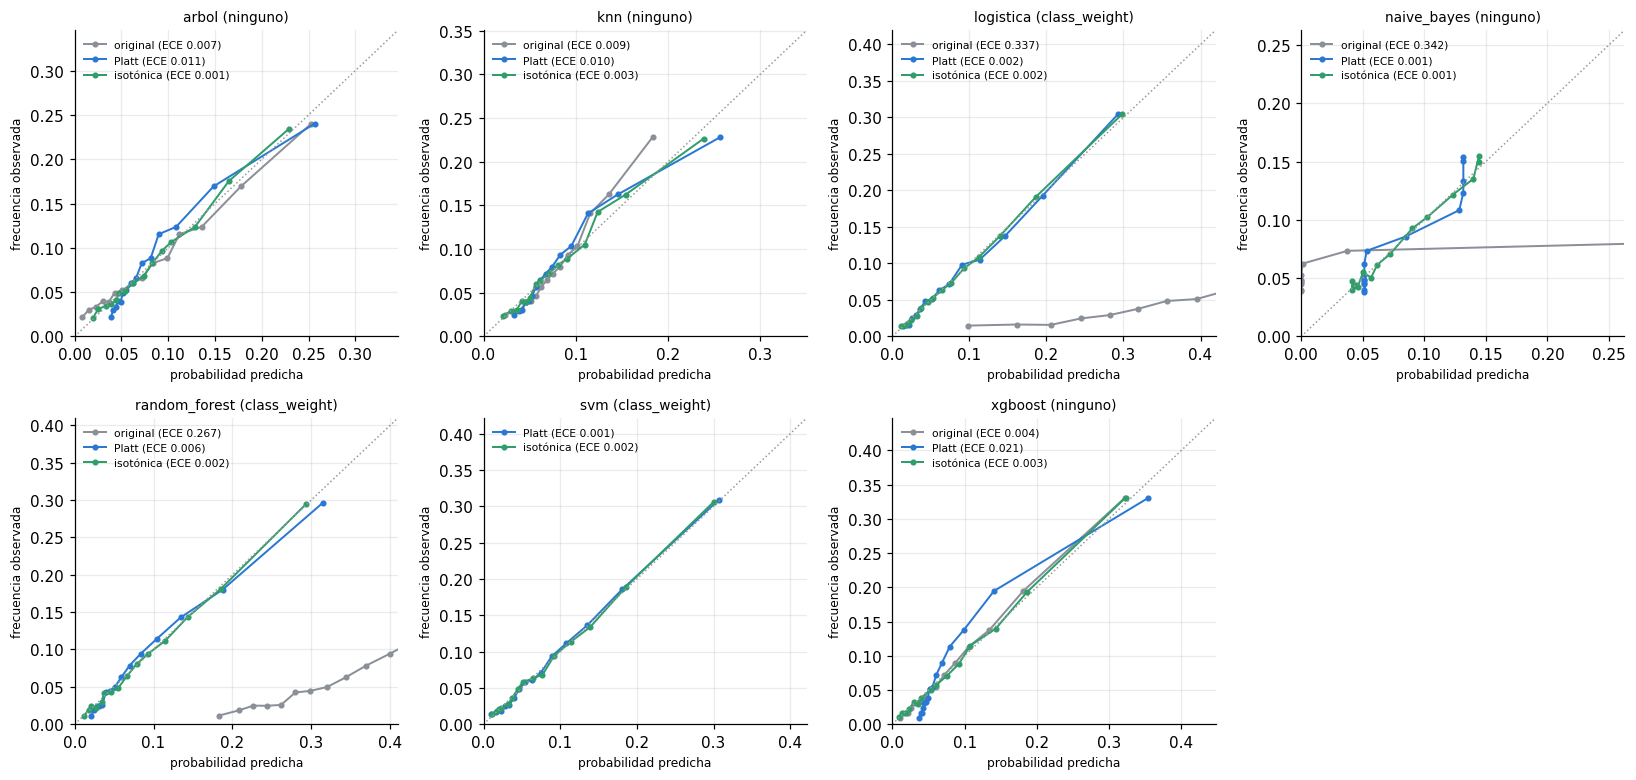

In [10]:
filas = []
fig, axes = plt.subplots(2, 4, figsize=(15, 7.2))
for ax, (m, d) in zip(axes.ravel(), F.items()):
    r = d["registro"]
    y, s = d["y"], d["s"]
    oof = ex.predicciones_oof("clasificacion", m, r["balanceo"], r["optimizador"])
    variantes = {}
    if mod.es_probabilidad("clasificacion", m):
        variantes["original"] = s
    variantes["Platt"] = met.recalibrar(oof["s"], oof["y"], s, "platt")
    variantes["isotónica"] = met.recalibrar(oof["s"], oof["y"], s, "isotonica")
    for i, (v, p) in enumerate(variantes.items()):
        cal = met.resumen_calibracion(y, p)
        filas.append({"modelo": m, "balanceo": r["balanceo"], "variante": v, **cal,
                      "auc": roc_auc_score(y, p)})
        pts = met.curva_confiabilidad(y, p, n_bins=15)
        ax.plot(pts[:, 0], pts[:, 1], marker="o", ms=3, lw=1.3, label=f"{v} (ECE {cal['ece']:.3f})",
                color=["#8a8f98", "#2a78d4", "#2f9e6b"][i + (0 if "original" in variantes else 1)])
    lim = max(0.05, float(np.nanmax(pts[:, :2])) * 1.05)
    ax.plot([0, 1], [0, 1], color="0.6", ls=":", lw=1)
    ax.set_xlim(0, min(1, lim + 0.1)); ax.set_ylim(0, min(1, lim + 0.1))
    ax.set_title(f"{m} ({r['balanceo']})", fontsize=9)
    ax.set_xlabel("probabilidad predicha", fontsize=8); ax.set_ylabel("frecuencia observada", fontsize=8)
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(F):]:
    ax.axis("off")
fig.tight_layout()
graficos.guardar(fig, "06_calibracion")
plt.show()
calibracion = pd.DataFrame(filas)
calibracion.to_csv(config.DIR_RESULTADOS / "calibracion_clasificacion.csv", index=False)
display(calibracion.pivot_table(index="modelo", columns="variante", values=["brier", "ece", "auc"])
        .style.format(precision=4))

**Lectura.** Llegan descalibrados exactamente los modelos que la teoría señalaba, y por las dos
vías. Por **balanceo**: la logística y Random Forest, ambos con `class_weight`, tienen un ECE de 0.34
y 0.27 y un Brier de 0.200 y 0.143; sobreestiman sistemáticamente la probabilidad porque entrenaron
con las clases igualadas (en el diagrama sus puntos caen a la derecha de la diagonal). Por
**algoritmo**: Naive Bayes, sin balanceo, tiene el peor ECE (0.34) y el peor Brier (0.336), porque
el supuesto de independencia empuja sus probabilidades a 0 y 1. SVM no produce probabilidades y solo
se evalúa recalibrado. Los modelos sin balanceo basados en árboles, vecinos o boosting llegan ya
razonablemente calibrados (ECE de 0.004 en XGBoost, 0.007 en el árbol y 0.009 en KNN).

La recalibración, ajustada con las predicciones fuera de muestra de desarrollo, resuelve el problema:
el ECE de la logística baja de 0.34 a 0.002 y su Brier de 0.200 a 0.068; el de Random Forest, de 0.27
a 0.002-0.006; el de Naive Bayes, de 0.34 a 0.001. La isotónica es la más fiable de las dos: en los
modelos que ya estaban calibrados, Platt empeora el ECE (XGBoost de 0.004 a 0.021, el árbol de 0.007
a 0.011) porque impone una forma sigmoide que no corresponde, mientras que la isotónica lo mejora en
todos los casos. Como Platt es una transformación monótona, no cambia el AUC (la tabla lo confirma, salvo una
diferencia de 0.0001 en Naive Bayes por puntajes saturados); la isotónica solo puede alterarlo por
los empates que introduce al asignar el mismo valor a tramos de puntajes, y lo baja a lo sumo 0.0006
(en el árbol).